In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")


df = pd.read_csv("/content/grocery_chain_data.csv")

print(f" dataframe head : {df.head()}")
print(f" dataframe shape : {df.shape}")
print(f" dataframe info : {df.info()}")



 dataframe head :    customer_id         store_name transaction_date           aisle  \
0         2824  GreenGrocer Plaza       2023-08-26         Produce   
1         5506   ValuePlus Market       2024-02-13           Dairy   
2         4657   ValuePlus Market       2023-11-23          Bakery   
3         2679  SuperSave Central       2025-01-13  Snacks & Candy   
4         9935  GreenGrocer Plaza       2023-10-13    Canned Goods   

   product_name  quantity  unit_price  total_amount  discount_amount  \
0         Pasta       2.0        7.46         14.92             0.00   
1        Cheese       1.0        1.85          1.85             3.41   
2        Onions       4.0        7.38         29.52             4.04   
3        Cereal       3.0        5.50         16.50             1.37   
4  Orange Juice       5.0        8.66         43.30             1.50   

   final_amount  loyalty_points  
0         14.92             377  
1         -1.56             111  
2         25.48           

In [34]:
y = df['final_amount']
df.drop(['customer_id', 'transaction_date', 'total_amount', 'discount_amount', 'final_amount'], axis = 1, inplace = True)
x = df
x_train, x_test, y_train, y_test = train_test_split(df, y, test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)


(1584, 6)
(396, 6)
(1584,)
(396,)


In [35]:
for col in x.columns:
  if x[col].dtype == 'object':
    x[col] = LabelEncoder().fit_transform(x[col])
  else:
    x[col] = StandardScaler().fit_transform(x[col].values.reshape(-1, 1))



In [36]:
print(x)

      store_name  aisle  product_name  quantity  unit_price  loyalty_points
0              4      9            12 -0.682457   -0.955867        0.834760
1              8      3             5 -1.387343   -1.623828       -0.987501
2              8      0            10  0.727314   -0.965393        0.314114
3              7     10             4  0.022428   -1.189237        1.608879
4              4      2            11  1.432200   -0.812988       -1.597205
...          ...    ...           ...       ...         ...             ...
1975           1      4            15  0.022428   -0.678444        0.129148
1976           0      8            13  0.727314    0.889656        1.190992
1977           5      3            13  0.022428    0.113345        0.410023
1978           6      4            14  1.432200    0.046668       -0.651821
1979           2      2            14 -0.682457    1.125407        0.067492

[1980 rows x 6 columns]


In [38]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Make copies to avoid modifying the original x_train, x_test and SettingWithCopyWarning
x_train_processed = x_train.copy()
x_test_processed = x_test.copy()

# Identify and process object columns in x_train_processed and x_test_processed
for col in x_train_processed.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    x_train_processed[col] = le.fit_transform(x_train_processed[col])

    # Apply the same fitted encoder to the test set, handling unseen labels by mapping them to -1
    x_test_processed[col] = x_test_processed[col].map(lambda s: le.transform([s])[0] if s in le.classes_ else -1)
    # Ensure the column type is integer after transformation
    x_test_processed[col] = x_test_processed[col].astype(int)

xgb_model = xgb.XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=-1)

xgb_model.fit(x_train_processed, y_train)

y_pred = xgb_model.predict(x_test_processed)

from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"""
 MSE : {mse},
 R2 : {r2}
 """)


 MSE : 39.74668440497647,
 R2 : 0.9610433257219375
 


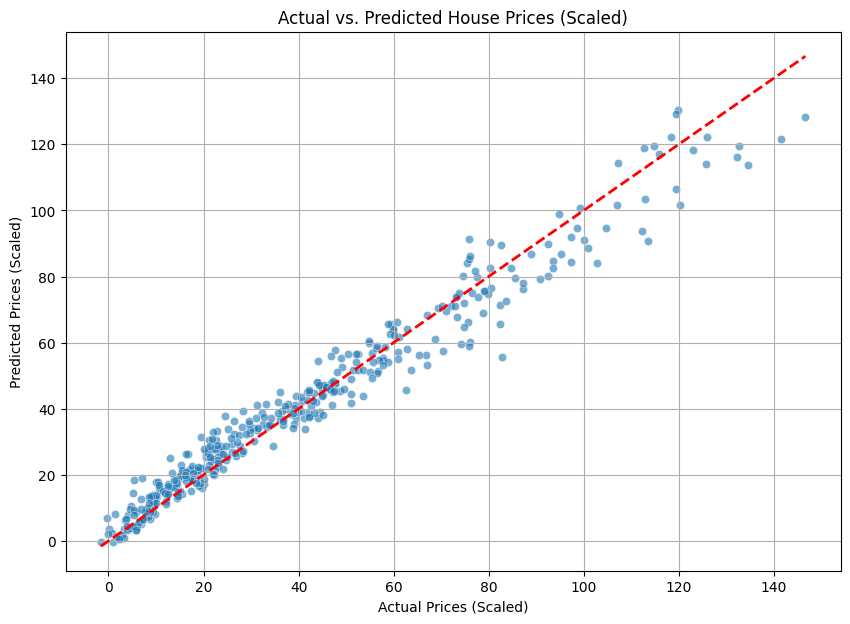

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.title('Actual vs. Predicted House Prices (Scaled)')
plt.xlabel('Actual Prices (Scaled)')
plt.ylabel('Predicted Prices (Scaled)')
plt.grid(True)
plt.show()

In [41]:
import joblib

joblib.dump(xgb_model, "xg boost model")
print("Model saved as xg boost ")

Model saved as xg boost 
